# **1. Imports and Config**

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib

### **1.1 Paths**

In [3]:
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "spotify_cleaned.csv"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
TABLES_PATH = PROJECT_ROOT / "outputs" / "tables"
MODELS_PATH = PROJECT_ROOT / "outputs" / "models"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

### **1.2 Load Data**

In [5]:
# Updated path to load the file from Google Drive
data_file_path = Path("/content/drive/MyDrive/spotify-popularity-prediction/data/processed/spotify_cleaned.csv")

try:
    df = pd.read_csv(data_file_path)

    print(f"Dataset shape: {df.shape}")
    print("First 10 rows of the DataFrame:")
    print(df.head(10))
except FileNotFoundError:
    print(f"Error: The file '{data_file_path}' was not found.")
    print("Please ensure the file exists at this Google Drive path and that your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Dataset shape: (89740, 133)
First 10 rows of the DataFrame:
                 track_id                   artists                album_name  \
0  0000vdREvCVMxbQTkS888c                      Rill                     Lolly   
1  000CC8EParg64OmTxVnZ0p                 Glee Cast           Glee Love Songs   
2  000Iz0K615UepwSJ5z2RE5  Paul Kalkbrenner;Pig&Dan                         X   
3  000RDCYioLteXcutOjeweY             Jordan Sandhu                Teeje Week   
4  000qpdoc97IMTBvF8gwcpy          Paul Kalkbrenner                      Zeit   
5  0017XiMkqbTfF2AUOzlhj6              Chad Daniels        Busy Being Awesome   
6  001APMDOl3qtx1526T11n1         Pink Sweat$;Kirby                   New RnB   
7  001YQlnDSduXd5LgBd66gT               Soda Stereo  Soda Stereo (Remastered)   
8  001pyq8FLNSL1C8orNLI0b    Old Crow Medicine Show                  O.C.M.S.   
9  002qpSULhHAw6DGqFxbaO1        Tokyo Ghetto Pussy                Disco 2001   

                                          track_

# **2. Modelling**

### **2.1 Define Target and Features**

In [6]:
TARGET = "popularity"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (89740, 132)
Target vector shape: (89740,)


In the next cell we remove the columns that are not needed for the modelling

In [8]:
metadata_columns = [
    "track_id",
    "artists",
    "album_name",
    "track_name"
]

X = df.drop(columns=[TARGET] + metadata_columns)
y = df[TARGET]

In [9]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

### **2.2 Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (71792, 128)
Test set: (17948, 128)


The dataset was split into training and testing sets before scaling or model fitting. This avoids data leakage by ensuring that transformations are learned only from the training data.

### **2.3 Evaluation Function**

In [11]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    results = {
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Test MAE": mean_absolute_error(y_test, test_predictions),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_predictions)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_predictions)),
        "Train R2": r2_score(y_train, train_predictions),
        "Test R2": r2_score(y_test, test_predictions)
    }

    return results, test_predictions

### **2.4 Baseline Model**

In [12]:
baseline_model = DummyRegressor(strategy="mean")

baseline_results, baseline_predictions = evaluate_regression_model(
    baseline_model,
    X_train,
    X_test,
    y_train,
    y_test
)

baseline_results

{'Train MAE': 17.227786068554952,
 'Test MAE': 17.252057273621453,
 'Train RMSE': np.float64(20.572630179643674),
 'Test RMSE': np.float64(20.612420893360724),
 'Train R2': 0.0,
 'Test R2': -0.00016677779870044596}

### **2.5 Model Training**

In [13]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [14]:
model_results = []

predictions = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    results, test_predictions = evaluate_regression_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["Model"] = model_name
    model_results.append(results)
    predictions[model_name] = test_predictions

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...


# **3. Results**

### **3.1 Results Table**

In [15]:
results_df = pd.DataFrame(model_results)

results_df = results_df[
    [
        "Model",
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE",
        "Train R2",
        "Test R2"
    ]
]

results_df.sort_values("Test RMSE")

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Random Forest,3.667316,9.658050,5.818300,14.520511,0.920014,0.503661
1,Ridge Regression,11.789575,11.917869,16.480391,16.650747,0.358265,0.347348
0,Linear Regression,11.789547,11.917845,16.480391,16.650752,0.358266,0.347347
3,Gradient Boosting,13.930007,14.086819,17.437683,17.649068,0.281548,0.266740


In [16]:
results_df.to_csv(
    TABLES_PATH / "model_comparison_results.csv",
    index=False
)

### **3.2 Model Comparison Plot**

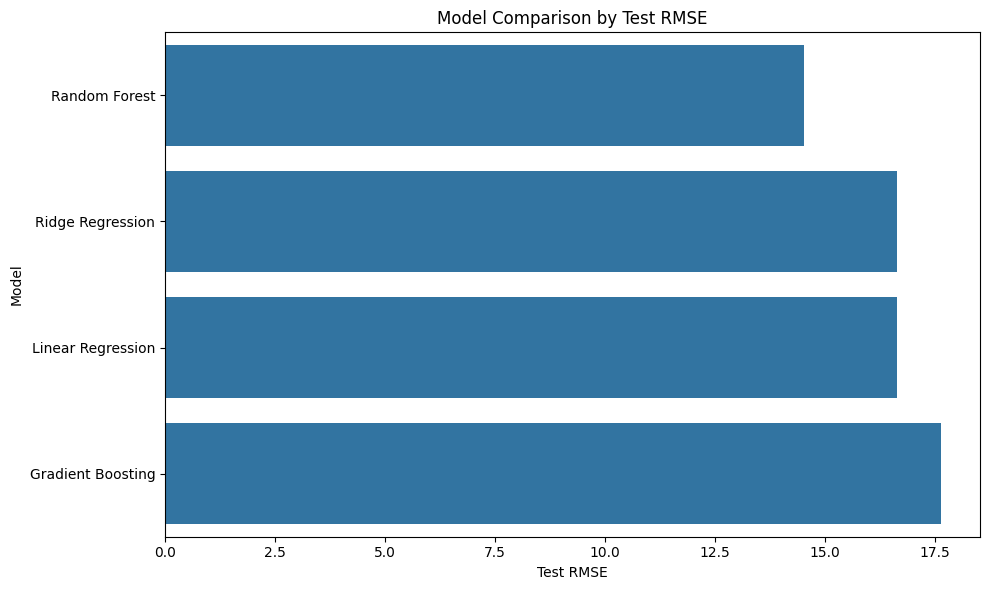

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df.sort_values("Test RMSE"),
    x="Test RMSE",
    y="Model"
)

plt.title("Model Comparison by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "model_comparison_rmse.png",
    dpi=300
)

plt.show()

### **3.3 Prediction Error Analysis**

In [18]:
best_model_name = results_df.sort_values("Test RMSE").iloc[0]["Model"]
best_predictions = predictions[best_model_name]

print(f"Best model: {best_model_name}")

Best model: Random Forest


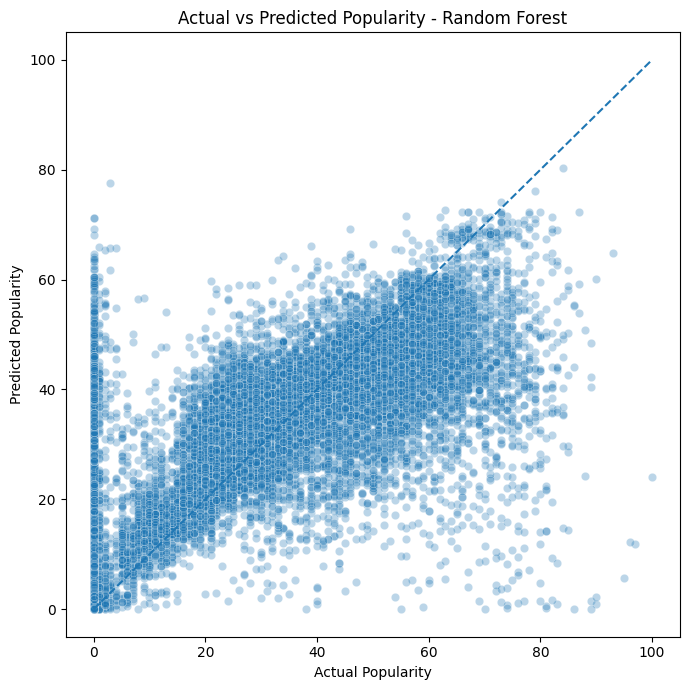

In [19]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Popularity - {best_model_name}")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "actual_vs_predicted.png",
    dpi=300
)

plt.show()

Residuals

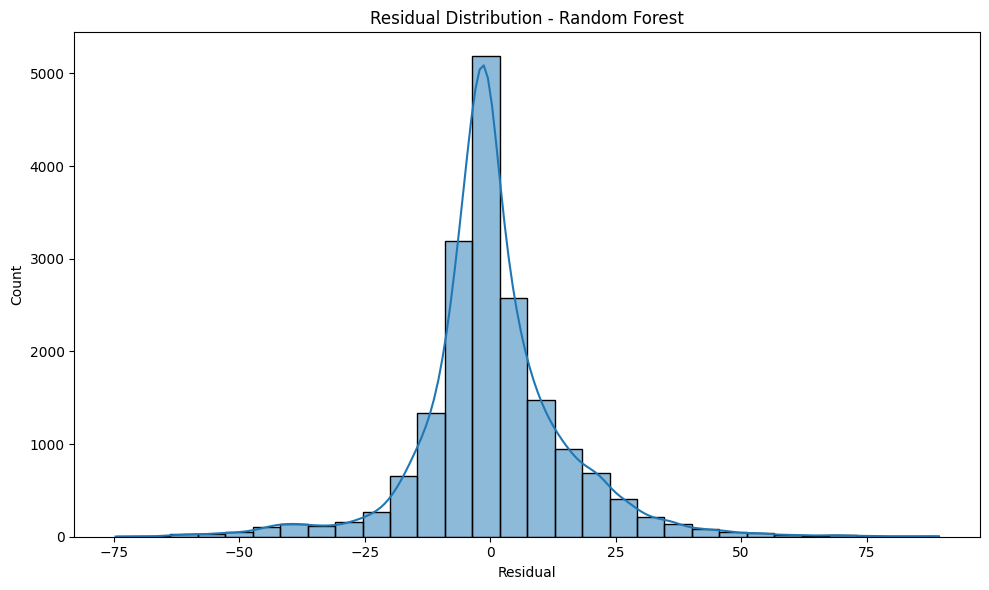

In [20]:
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "residual_distribution.png",
    dpi=300
)

plt.show()

### **3.4 Feature Importance**

In [21]:
best_model = models[best_model_name]

In [22]:
if hasattr(best_model, "feature_importances_"):

    feature_importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    feature_importance_df.head(20)

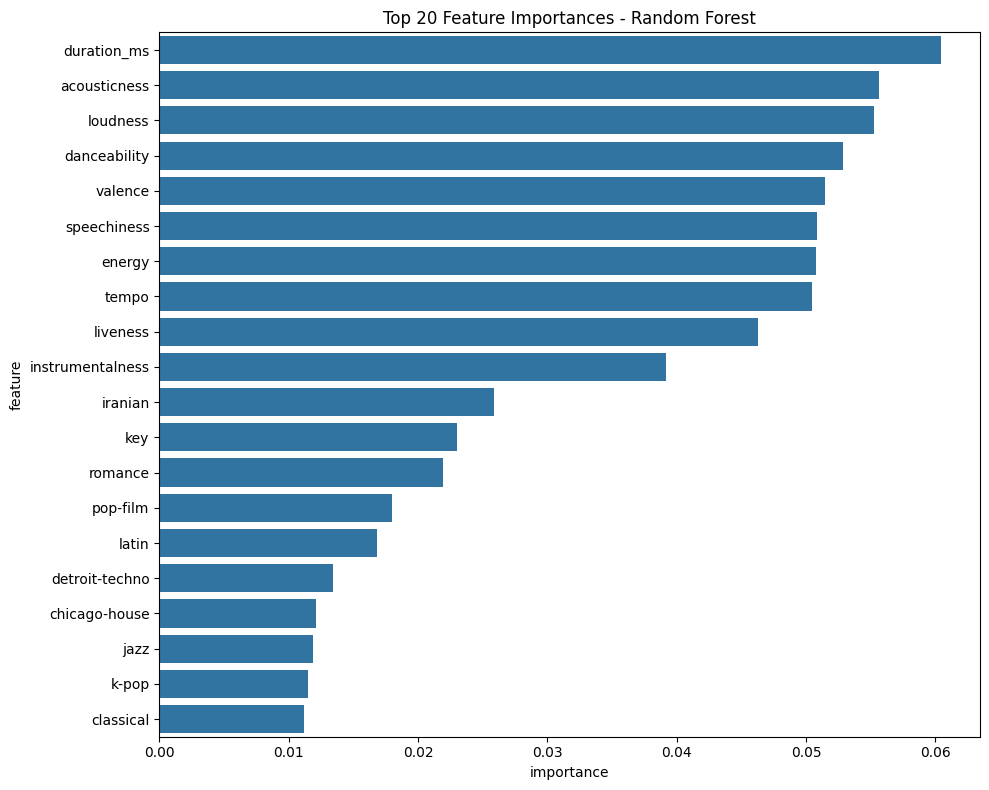

In [23]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title(f"Top 20 Feature Importances - {best_model_name}")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "feature_importance.png",
    dpi=300
)

plt.show()

### **3.5 Investigate duration outliers**

In [24]:
df["duration_minutes"] = df["duration_ms"] / 60000

In [25]:
df["duration_minutes"].describe()

,duration_minutes
count,89740.000000
mean,3.819073
std,1.882430
min,0.143100
25%,2.884000
50%,3.554925
75%,4.404883
max,87.288250


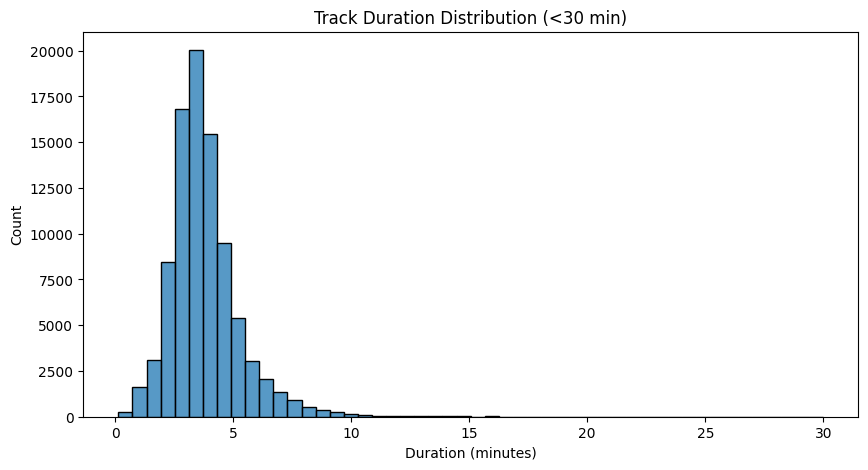

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[df["duration_minutes"] < 30]["duration_minutes"],
    bins=50
)

plt.title("Track Duration Distribution (<30 min)")
plt.xlabel("Duration (minutes)")

plt.show()

Analysis shows that most tracks exhibit realistic music durations centred around approximately 3–4 minutes, although a small number of long-duration outliers exist.

This suggests that track duration may genuinely influence popularity patterns, potentially reflecting listener preferences for radio-friendly song lengths or differences between mainstream and niche audio content

# **4. Conclusions**

### **4.1 Modelling Performance**
Several regression models were trained and evaluated to predict Spotify track popularity using audio characteristics and aggregated genre features. A dummy baseline regressor was first established to provide a minimum performance benchmark, achieving a Test RMSE of approximately 20.6 and near-zero explanatory power.

Both Linear Regression and Ridge Regression substantially outperformed the baseline model, achieving Test R² scores of approximately 0.35. This indicates that the dataset contains meaningful predictive signal, although the relationships between features and popularity are not purely linear.

Among all evaluated models, the Random Forest achieved the strongest predictive performance, with:

*   Test RMSE ≈ 14.5
*   Test MAE ≈ 9.7
*   Test R² ≈ 0.50

This suggests that approximately half of the variance in Spotify popularity can be explained using the available audio and genre features. The superior performance of the Random Forest model compared to linear approaches indicates that popularity is influenced by complex and non-linear interactions between musical characteristics.

### **4.2 Model Behaviour and Error Analysis**
Residual analysis demonstrated that prediction errors were generally centred around zero and followed an approximately bell-shaped distribution, indicating that the model does not exhibit severe systematic bias.

However, the Actual vs Predicted plot revealed that the model struggles to accurately predict extreme popularity values. Highly popular tracks are frequently underpredicted, while some low-popularity tracks are overpredicted. This behaviour is consistent with regression models tending to predict toward the mean and suggests that factors external to the dataset likely influence popularity outcomes.

Potential missing factors could be artist reputation, marketing exposure, playlist placement, social media exposure, release timing, among others. These variables are not captured within the current dataset.

### **4.3 Overall Assessment**
The modelling results demonstrate that Spotify popularity can be partially predicted using intrinsic audio features and genre information. However, the moderate performance ceiling observed across models suggests that popularity is also heavily influenced by external social and commercial factors beyond the scope of the dataset.
